In [ ]:
pip install --upgrade langgraph langchain dotenv langchain-groq

In [ ]:
!pip install --upgrade langchain langchain-google-genai pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 50.9 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [ ]:
# 1. Install required packages (Uncomment if you haven't installed these in Colab yet)
# !pip install langchain-core langgraph pydantic langchain-google-genai langchain-groq python-dotenv pillow

# 2. Imports from your original setup
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from langgraph.graph import StateGraph, START, END
import operator
from typing import TypedDict, Annotated, Optional, List, Literal, Dict, Any
from pydantic import BaseModel, Field, ValidationError, model_validator
from langchain_core.messages import HumanMessage, BaseMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI
import base64
from PIL import Image
import json

In [ ]:


# 3. Model Initialization
api_key ="AQ.Ab8RN6J3ZsrEalxthqxamQG9_FrhOA5DZOQPgEKoS1S5Rnzg4A"

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=api_key
)
# 4. Image Encoding Function
def encode_image(image_path):
    """Convert image to base64"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

print("Successful - Environment, LLM, and Image Encoder are ready!")

Successful - Environment, LLM, and Image Encoder are ready!


In [ ]:
# =============================================================================
# 1. STRUCTURED LLM OUTPUT MODELS  (diagram-derived information ONLY)
# =============================================================================

class ActorDetail(BaseModel):
    name: str
    classification: Literal["Simple", "Average", "Complex"]
    evidence: str

class ActorList(BaseModel):
    actors: List[ActorDetail] = Field(min_length=1)

class UseCaseDetail(BaseModel):
    name: str
    transaction_count: Optional[int]
    complexity: Literal["Simple", "Average", "Complex", "Undetermined"]
    evidence: str

    @model_validator(mode='after')
    def validate_complexity(self):
        if self.complexity == "Undetermined":
            if self.transaction_count is not None:
                raise ValueError("Undetermined use case must have null transaction_count")
        elif self.complexity == "Simple":
            if self.transaction_count is None or not (1 <= self.transaction_count <= 3):
                raise ValueError("Simple use case requires explicit transaction count between 1 and 3")
        elif self.complexity == "Average":
            if self.transaction_count is None or not (4 <= self.transaction_count <= 7):
                raise ValueError("Average use case requires explicit transaction count between 4 and 7")
        elif self.complexity == "Complex":
            if self.transaction_count is None or self.transaction_count <= 7:
                raise ValueError("Complex use case requires explicit transaction count greater than 7")
        return self

class UseCaseList(BaseModel):
    use_cases: List[UseCaseDetail] = Field(min_length=1)

In [ ]:
# =============================================================================
# 2. USER-PROVIDED PROJECT INPUT  (TCF / ECF)
# =============================================================================

TECHNICAL_FACTOR_WEIGHTS: Dict[str, float] = {
    "T1": 2.0, "T2": 1.0, "T3": 1.0, "T4": 1.0, "T5": 1.0, "T6": 0.5,
    "T7": 0.5, "T8": 2.0, "T9": 1.0, "T10": 1.0, "T11": 1.0, "T12": 1.0, "T13": 1.0,
}

ENVIRONMENTAL_FACTOR_WEIGHTS: Dict[str, float] = {
    "E1": 1.5, "E2": 0.5, "E3": 1.0, "E4": 0.5, "E5": 1.0, "E6": 2.0,
    "E7": -1.0, "E8": -1.0,
}

class TCFInput(BaseModel):
    T1: int = Field(ge=0, le=5); T2: int = Field(ge=0, le=5); T3: int = Field(ge=0, le=5)
    T4: int = Field(ge=0, le=5); T5: int = Field(ge=0, le=5); T6: int = Field(ge=0, le=5)
    T7: int = Field(ge=0, le=5); T8: int = Field(ge=0, le=5); T9: int = Field(ge=0, le=5)
    T10: int = Field(ge=0, le=5); T11: int = Field(ge=0, le=5); T12: int = Field(ge=0, le=5)
    T13: int = Field(ge=0, le=5)

class ECFInput(BaseModel):
    E1: int = Field(ge=0, le=5); E2: int = Field(ge=0, le=5); E3: int = Field(ge=0, le=5)
    E4: int = Field(ge=0, le=5); E5: int = Field(ge=0, le=5); E6: int = Field(ge=0, le=5)
    E7: int = Field(ge=0, le=5); E8: int = Field(ge=0, le=5)

def validate_tcf_input(raw: Dict[str, Any]) -> Dict[str, Any]:
    try:
        return {"ok": True, "data": TCFInput(**raw).model_dump()}
    except ValidationError as e:
        return {"ok": False, "error": f"Invalid TCF input: {e}"}

def validate_ecf_input(raw: Dict[str, Any]) -> Dict[str, Any]:
    try:
        return {"ok": True, "data": ECFInput(**raw).model_dump()}
    except ValidationError as e:
        return {"ok": False, "error": f"Invalid ECF input: {e}"}

In [ ]:
# =============================================================================
# 3. STATE
# =============================================================================

class DiagramState(TypedDict):
    image_data: str
    tcf_ratings_raw: Dict[str, Any]
    ecf_ratings_raw: Dict[str, Any]

    actor_status: str
    actor_error: Optional[str]
    usecase_status: str
    usecase_error: Optional[str]

    _actors: Optional[List[Dict[str, Any]]]
    _use_cases: Optional[List[Dict[str, Any]]]

    tcf_input_status: str
    tcf_input_error: Optional[str]
    _tcf_ratings: Optional[Dict[str, Any]]  # Added missing field

    ecf_input_status: str
    ecf_input_error: Optional[str]
    _ecf_ratings: Optional[Dict[str, Any]]  # Added missing field

    UAW: Optional[int]
    UUCW: Optional[int]

    partial_uucw: Optional[int]
    uucw_status: Optional[str]

    UUCP: Optional[int]
    TCF: Optional[float]
    ECF: Optional[float]
    UCP: Optional[float]
    productivity_factor: Optional[int]
    complexity_bucket: Optional[str]
    Effort: Optional[float]

    pipeline_status: str
    pipeline_errors: List[str]

def _init_state_defaults(state: DiagramState) -> None:
    state.setdefault("pipeline_errors", [])

In [ ]:
# =============================================================================
# 4. LLM NODES — visual/semantic interpretation ONLY
# =============================================================================

def analyze_actors_node(state: DiagramState) -> dict:
    print("\n--- Analyzing Actors (LLM) ---")
    try:
        image_path = state["image_data"]
        prompt = """Analyze this use case diagram and identify each ACTOR individually.

For each actor (stick figure), determine:
- Simple Actor: External system with API
- Average Actor: External system with protocol OR human with text interface
- Complex Actor: Human with GUI

Only extract what is visually present in the diagram. Do not invent actors.

Return ONLY JSON:
{
  "actors": [
    {
      "name": "actor name",
      "classification": "Simple" | "Average" | "Complex",
      "evidence": "brief explanation based on diagram"
    }
  ]
}"""
        image_data = encode_image(image_path)
        message = HumanMessage(
            content=[
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": f"data:image/jpeg;base64,{image_data}"},
            ]
        )
        response = llm.invoke([message])

        # Safely extract text whether it is returned as a string or a list of blocks
        if isinstance(response.content, list):
            result_text = "".join(part.get("text", "") if isinstance(part, dict) else str(part) for part in response.content)
        else:
            result_text = str(response.content)

        result_text = result_text.strip().replace("```json", "").replace("```", "").strip()
        raw = json.loads(result_text)
        actor_list = ActorList(**raw)
        print(f"Extracted {len(actor_list.actors)} actors.")
        return {
            "actor_status": "ok",
            "actor_error": None,
            "_actors": [actor.model_dump() for actor in actor_list.actors],
        }
    except Exception as e:
        print(f"❌ Actor analysis failed: {e}")
        return {"actor_status": "failed", "actor_error": str(e)}

def analyze_usecases_node(state: DiagramState) -> dict:
    print("\n--- Analyzing Use Cases (LLM) ---")
    try:
        image_path = state["image_data"]
        prompt = """Analyze this use case diagram and extract each USE CASE individually.

For each use case, determine complexity STRICTLY based on explicitly visible transaction counts.
Do NOT use vague visual reasoning, number of relationships, or perceived business complexity.

RULES:
1. If transaction count is explicitly visible in the diagram:
   - 1-3 transactions -> "Simple"
   - 4-7 transactions -> "Average"
   - >7 transactions -> "Complex"
2. If transaction count is NOT explicitly visible in the diagram:
   - transaction_count = null
   - complexity = "Undetermined"

Return ONLY JSON:
{
  "use_cases": [
    {
      "name": "use case name",
      "transaction_count": integer or null,
      "complexity": "Simple" | "Average" | "Complex" | "Undetermined",
      "evidence": "explain where transaction count is seen, or state it is not available"
    }
  ]
}"""
        image_data = encode_image(image_path)
        message = HumanMessage(
            content=[
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": f"data:image/jpeg;base64,{image_data}"},
            ]
        )
        response = llm.invoke([message])

        # Safely extract text whether it is returned as a string or a list of blocks
        if isinstance(response.content, list):
            result_text = "".join(part.get("text", "") if isinstance(part, dict) else str(part) for part in response.content)
        else:
            result_text = str(response.content)

        result_text = result_text.strip().replace("```json", "").replace("```", "").strip()
        raw = json.loads(result_text)
        use_case_list = UseCaseList(**raw)
        print(f"Extracted {len(use_case_list.use_cases)} use cases.")
        return {
            "usecase_status": "ok",
            "usecase_error": None,
            "_use_cases": [uc.model_dump() for uc in use_case_list.use_cases],
        }
    except Exception as e:
        print(f"❌ Use case analysis failed: {e}")
        return {"usecase_status": "failed", "usecase_error": str(e)}


In [ ]:
# =============================================================================
# 5 & 6. DETERMINISTIC CALCULATION NODES
# =============================================================================

def validate_tcf_node(state: DiagramState) -> dict:
    print("\n--- Validating User-Provided TCF Ratings ---")
    result = validate_tcf_input(state.get("tcf_ratings_raw", {}))
    if result["ok"]:
        return {"tcf_input_status": "ok", "tcf_input_error": None, "_tcf_ratings": result["data"]}
    return {"tcf_input_status": "failed", "tcf_input_error": result["error"]}

def validate_ecf_node(state: DiagramState) -> dict:
    print("\n--- Validating User-Provided ECF Ratings ---")
    result = validate_ecf_input(state.get("ecf_ratings_raw", {}))
    if result["ok"]:
        return {"ecf_input_status": "ok", "ecf_input_error": None, "_ecf_ratings": result["data"]}
    return {"ecf_input_status": "failed", "ecf_input_error": result["error"]}

def compute_uaw_node(state: DiagramState) -> dict:
    print("\n--- Computing UAW (deterministic) ---")
    if state.get("actor_status") != "ok": return {"UAW": None}
    actors = state.get("_actors", [])
    simple = sum(1 for a in actors if a["classification"] == "Simple")
    average = sum(1 for a in actors if a["classification"] == "Average")
    complex_ = sum(1 for a in actors if a["classification"] == "Complex")
    uaw = (simple * 1) + (average * 2) + (complex_ * 3)
    return {"UAW": uaw}

def compute_uucw_node(state: DiagramState) -> dict:
    print("\n--- Computing UUCW (deterministic) ---")
    if state.get("usecase_status") != "ok": return {"UUCW": None, "uucw_status": "failed"}
    use_cases = state.get("_use_cases", [])
    has_undetermined = any(uc["complexity"] == "Undetermined" for uc in use_cases)
    partial_uucw = 0
    for uc in use_cases:
        if uc["complexity"] == "Simple": partial_uucw += 5
        elif uc["complexity"] == "Average": partial_uucw += 10
        elif uc["complexity"] == "Complex": partial_uucw += 15

    if has_undetermined:
        return {"UUCW": None, "partial_uucw": partial_uucw, "uucw_status": "incomplete_due_to_missing_transaction_information"}
    return {"UUCW": partial_uucw, "partial_uucw": partial_uucw, "uucw_status": "complete"}

def compute_uucp_node(state: DiagramState) -> dict:
    uaw, uucw = state.get("UAW"), state.get("UUCW")
    if uaw is None or uucw is None: return {"UUCP": None}
    return {"UUCP": uaw + uucw}

def compute_tcf_node(state: DiagramState) -> dict:
    if state.get("tcf_input_status") != "ok": return {"TCF": None}
    ratings = state["_tcf_ratings"]
    tfactor = sum(ratings[factor] * weight for factor, weight in TECHNICAL_FACTOR_WEIGHTS.items())
    return {"TCF": 0.6 + (tfactor / 100)}

def compute_ecf_node(state: DiagramState) -> dict:
    if state.get("ecf_input_status") != "ok": return {"ECF": None}
    ratings = state["_ecf_ratings"]
    efactor = sum(ratings[factor] * weight for factor, weight in ENVIRONMENTAL_FACTOR_WEIGHTS.items())
    return {"ECF": 1.4 + (-0.03 * efactor)}

def compute_ucp_node(state: DiagramState) -> dict:
    uucp, tcf, ecf = state.get("UUCP"), state.get("TCF"), state.get("ECF")
    if None in (uucp, tcf, ecf): return {"UCP": None}
    return {"UCP": uucp * tcf * ecf}

def compute_effort_node(state: DiagramState) -> dict:
    ucp, tcf, ecf = state.get("UCP"), state.get("TCF"), state.get("ECF")
    if None in (ucp, tcf, ecf): return {"Effort": None, "productivity_factor": None, "complexity_bucket": None}

    if tcf > 1.0 and ecf < 1.0: productivity_factor, complexity = 28, "Complex"
    elif tcf < 0.8 and ecf > 1.2: productivity_factor, complexity = 20, "Simple"
    else: productivity_factor, complexity = 24, "Average"

    return {"Effort": ucp * productivity_factor, "productivity_factor": productivity_factor, "complexity_bucket": complexity}


def aggregate_results_node(state: DiagramState) -> dict:
    errors = list(state.get("pipeline_errors", []))
    for status_field, err_field, label in [
        ("actor_status", "actor_error", "Actor extraction"),
        ("usecase_status", "usecase_error", "Use case extraction"),
        ("tcf_input_status", "tcf_input_error", "TCF input validation"),
        ("ecf_input_status", "ecf_input_error", "ECF input validation"),
    ]:
        if state.get(status_field) == "failed":
            errors.append(f"{label} failed: {state.get(err_field)}")

    # CHANGED FOR PIPELINE STATUS LOGIC
    if errors:
        status = "failed"
    elif state.get("Effort") is not None:
        status = "ok"
    elif state.get("uucw_status") == "incomplete_due_to_missing_transaction_information":
        status = "incomplete"
    else:
        status = "failed"

    print(f"\n=== Pipeline status: {status} ===")
    if errors:
        for e in errors:
            print(f"  - {e}")

    return {"pipeline_status": status, "pipeline_errors": errors}

In [ ]:
# =============================================================================
# 7. GRAPH ASSEMBLY
# =============================================================================

workflow = StateGraph(DiagramState)

workflow.add_node("AnalyzeActors", analyze_actors_node)
workflow.add_node("AnalyzeUseCases", analyze_usecases_node)
workflow.add_node("ValidateTCF", validate_tcf_node)
workflow.add_node("ValidateECF", validate_ecf_node)

workflow.add_node("UAW", compute_uaw_node)
workflow.add_node("UUCW", compute_uucw_node)
workflow.add_node("UUCP", compute_uucp_node)
workflow.add_node("TCF", compute_tcf_node)
workflow.add_node("ECF", compute_ecf_node)
workflow.add_node("UCP", compute_ucp_node)
workflow.add_node("Effortcalc", compute_effort_node)
workflow.add_node("Aggregate", aggregate_results_node)

# Explicit parallel START edges
workflow.add_edge(START, "AnalyzeActors")
workflow.add_edge(START, "AnalyzeUseCases")
workflow.add_edge(START, "ValidateTCF")
workflow.add_edge(START, "ValidateECF")

# Diagram-derived path
workflow.add_edge("AnalyzeActors", "UAW")
workflow.add_edge("AnalyzeUseCases", "UUCW")
workflow.add_edge("UAW", "UUCP")
workflow.add_edge("UUCW", "UUCP")

# Project-provided path
workflow.add_edge("ValidateTCF", "TCF")
workflow.add_edge("ValidateECF", "ECF")

# ==== STATIC FAN-IN EDGES ====
workflow.add_edge("UUCP", "UCP")
workflow.add_edge("TCF", "UCP")
workflow.add_edge("ECF", "UCP")

# Downstream path
workflow.add_edge("UCP", "Effortcalc")
workflow.add_edge("Effortcalc", "Aggregate")
workflow.add_edge("Aggregate", END)

app = workflow.compile()

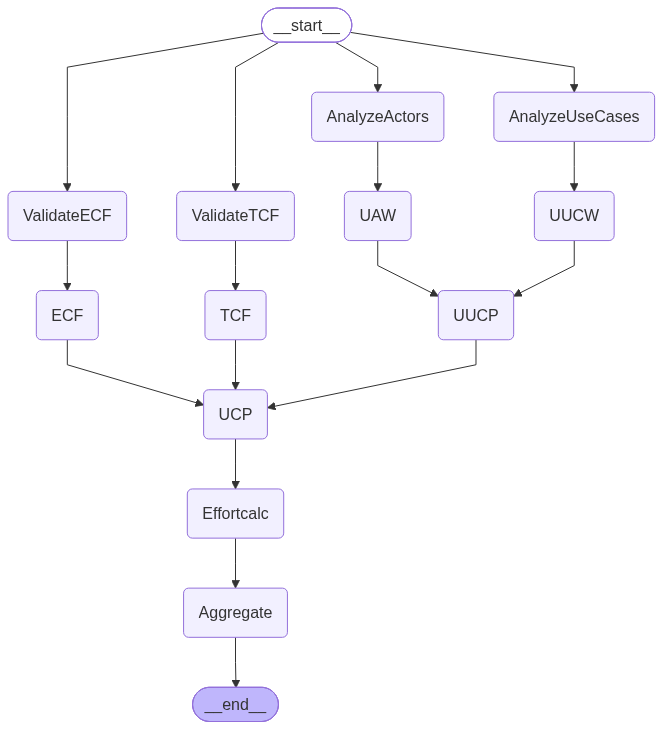

In [ ]:
app

In [ ]:
# =============================================================================
# 8. EXAMPLE INVOCATION
# =============================================================================

# ⚠️ Change this to an actual image uploaded to your Colab session
warehouse_inventory_input = {
    "image_data": "/content/drive/MyDrive/ResearchImagesUML/Research images/warehouse inventory.png",
    "tcf_ratings_raw": {
        "T1": 4, "T2": 4, "T3": 3, "T4": 4, "T5": 3, "T6": 3, "T7": 3,
        "T8": 2, "T9": 4, "T10": 4, "T11": 3, "T12": 4, "T13": 2,
    },
    "ecf_ratings_raw": {
        "E1": 4, "E2": 5, "E3": 4, "E4": 4, "E5": 4, "E6": 4, "E7": 1, "E8": 0,
    },
    "pipeline_errors": [],
}

final_state = app.invoke(warehouse_inventory_input)

print("\n\n========== RESULTS ==========")
print("-- Diagram Analysis --")
print(f"UAW:  {final_state.get('UAW')}")
print(f"UUCW: {final_state.get('UUCW')} (Status: {final_state.get('uucw_status')})")
print(f"UUCP: {final_state.get('UUCP')}")
print("\n-- Project Inputs (user-provided) --")
print(f"TCF:  {final_state.get('TCF'):.3f}" if final_state.get("TCF") else "TCF: N/A")
print(f"ECF:  {final_state.get('ECF'):.3f}" if final_state.get("ECF") else "ECF: N/A")
print("\n-- Final Calculation --")
print(f"UCP:  {final_state.get('UCP')}")
print(f"Productivity factor: {final_state.get('productivity_factor')} hrs/UCP "
      f"({final_state.get('complexity_bucket')})")
print(f"Effort: {final_state.get('Effort')}")
print(f"\nPipeline status: {final_state.get('pipeline_status')}")
if final_state.get("pipeline_errors"):
    print(f"Errors: {final_state.get('pipeline_errors')}")


--- Analyzing Actors (LLM) ---

--- Analyzing Use Cases (LLM) ---

--- Validating User-Provided ECF Ratings ---

--- Validating User-Provided TCF Ratings ---


/usr/local/lib/python3.12/dist-packages/langchain_google_genai/chat_models.py:3237: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Extracted 16 use cases.
Extracted 5 actors.

--- Computing UAW (deterministic) ---

--- Computing UUCW (deterministic) ---

=== Pipeline status: failed ===

=== Pipeline status: ok ===


========== RESULTS ==========
-- Diagram Analysis --
UAW:  15
UUCW: 150 (Status: complete)
UUCP: 165

-- Project Inputs (user-provided) --
TCF:  1.060
ECF:  0.635

-- Final Calculation --
UCP:  111.06149999999998
Productivity factor: 28 hrs/UCP (Complex)
Effort: 3109.7219999999993

Pipeline status: ok


In [ ]:
# 17. Pharmacy Management System


# 18. Property Management System


# 19. Railway Reservation System


# 20. Restaurant Management System


# 21. Smart Home Automation System

# 22. Vehicle Rental Management System


# 23. Vehicle Service Center Management System

# 24. Warehouse Inventory Management System


In [ ]:
import pandas as pd

# The parsed data from your 25 pipeline runs
data = [
    [1, "Agriculture", 5, 15, 12, 150, 162, 0.945, 0.800, 122.47, 24, 2939.33, "OK"],
    [2, "Airline", 4, 15, 10, 125, 135, 1.175, 0.665, 105.49, 28, 2953.60, "OK"],
    [3, "Banking", 5, 20, 12, 200, 212, 1.100, 0.605, 141.09, 28, 3950.41, "OK"],
    [4, "BloodBank", 5, 16, 15, 155, 170, 1.030, 0.710, 124.32, 28, 3480.99, "OK"],
    [5, "Bookstore", 3, 15, 7, 110, 117, 1.080, 0.650, 82.13, 28, 2299.75, "OK"],
    [6, "CarPool", 5, 16, 13, 135, 148, 1.170, 0.785, 135.93, 28, 3806.06, "OK"],
    [7, "ELearning", 4, 16, 10, 140, 150, 1.010, 0.755, 114.38, 28, 3202.71, "OK"],
    [8, "EventMgmt", 5, 17, 13, 145, 158, 1.055, 0.860, 143.35, 28, 4013.90, "OK"],
    [9, "Food Delivery", 5, 25, 13, None, None, 1.145, 0.725, None, None, None, "Incomplete"],
    [10, "Gym", 5, 16, 13, 150, 163, 0.950, 0.650, 100.65, 24, 2415.66, "OK"],
    [11, "Hospital", 6, 16, 16, 160, 176, 1.135, 0.650, 129.84, 28, 3635.63, "OK"],
    [12, "Hotel Reservation", 5, 20, 13, 185, 198, 1.085, 0.605, 129.97, 28, 3639.22, "OK"],
    [13, "Job Recruitment", 5, 16, 13, 145, 158, 1.080, 0.830, 141.63, 28, 3965.67, "OK"],
    [14, "Library", 4, 16, 10, 150, 160, 0.970, 0.560, 86.91, 24, 2085.89, "OK"],
    [15, "Movie Ticket", 4, 16, 10, 130, 140, 1.095, 0.665, 101.94, 28, 2854.45, "OK"],
    [16, "Parking", 5, 16, 11, 135, 146, 1.035, 0.815, 123.15, 28, 3448.33, "OK"],
    [17, "Pharmacy", 4, 15, 12, 140, 152, 1.075, 0.605, 98.86, 28, 2768.00, "OK"],
    [18, "Property Mgmt", 5, 19, 13, 180, 193, 1.070, 0.800, 165.21, 28, 4625.82, "OK"],
    [19, "Railway", 5, 19, 14, 185, 199, 1.175, 0.635, 148.48, 28, 4157.41, "OK"],
    [20, "Restaurant", 5, 16, 13, 145, 158, 1.000, 0.725, 114.55, 24, 2749.20, "OK"],
    [21, "Smart Automation", 5, 15, 10, 140, 150, 1.155, 0.860, 148.99, 28, 4171.86, "OK"],
    [22, "Vehicle Rental", 4, 15, 10, 135, 145, 1.080, 0.695, 108.84, 28, 3047.44, "OK"],
    [23, "Vehicle Service", 5, 16, 15, 155, 170, 1.020, 0.665, 115.31, 28, 3228.71, "OK"],
    [24, "Warehousing", 5, 16, 15, 150, 165, 1.060, 0.635, 111.06, 28, 3109.72, "OK"],
    [25, "University", 3, 15, 7, 110, 117, 0.950, 0.785, 87.25, 24, 2094.07, "OK"]
]

columns = [
    "ID", "System / Domain", "Actors Extracted", "Use Cases Extracted",
    "UAW", "UUCW", "UUCP", "TCF", "ECF", "UCP",
    "Productivity Factor", "Effort (Person-Hours)", "Pipeline Status"
]

# Create DataFrame and export to Excel
df = pd.DataFrame(data, columns=columns)
file_path = "/content/drive/MyDrive/UCP_Synthetic_Results.xlsx"
df.to_excel(file_path, index=False)

print(f"Success! Your Excel file is saved at: {file_path}")

Success! Your Excel file is saved at: /content/drive/MyDrive/UCP_Synthetic_Results.xlsx


✅ Saved Fig 1 successfully!


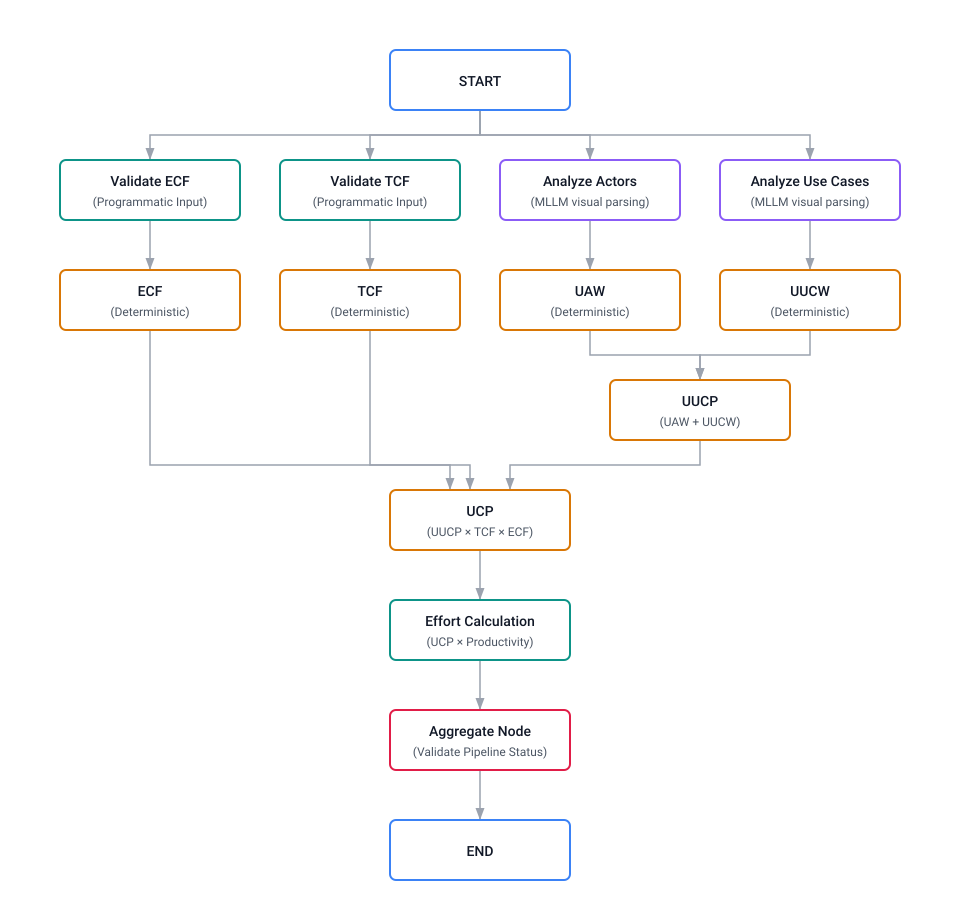


✅ Saved Fig 2 successfully!


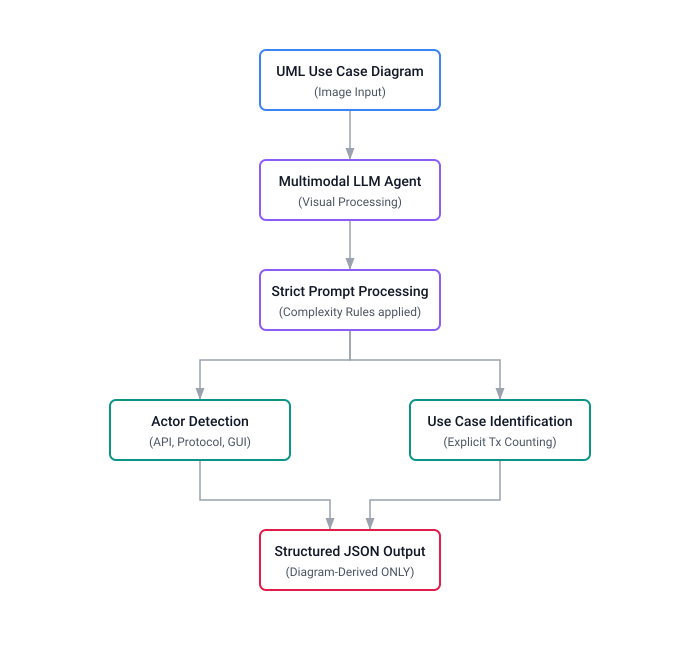

In [ ]:
import os
from IPython.display import SVG, display

# ==========================================
# Common SVG Theme Elements
# ==========================================
svg_defs = """
  <defs>
    <style>
      .node-text { font-family: 'Segoe UI', -apple-system, BlinkMacSystemFont, Roboto, Arial, sans-serif; fill: #111827; font-size: 14px; text-anchor: middle; font-weight: 500; }
      .node-subtext { font-family: 'Segoe UI', -apple-system, BlinkMacSystemFont, Roboto, Arial, sans-serif; fill: #4b5563; font-size: 12px; text-anchor: middle; }
      .arrow-line { stroke: #9ca3af; stroke-width: 1.5; fill: none; }
      .box { fill: #ffffff; stroke-width: 2; }
    </style>
    <marker id="arrowhead" markerWidth="8" markerHeight="6" refX="8" refY="3" orient="auto">
      <polygon points="0 0, 8 3, 0 6" fill="#9ca3af"/>
    </marker>
  </defs>
"""

# Helper to generate boxes
def rect(x, y, stroke, t1, t2=""):
    # x, y is top left. Width 180, Height 60
    box_svg = f'<rect x="{x}" y="{y}" width="180" height="60" rx="6" class="box" stroke="{stroke}" />\n'
    if t2:
        box_svg += f'<text x="{x+90}" y="{y+26}" class="node-text">{t1}</text>\n'
        box_svg += f'<text x="{x+90}" y="{y+46}" class="node-subtext">{t2}</text>\n'
    else:
        box_svg += f'<text x="{x+90}" y="{y+36}" class="node-text">{t1}</text>\n'
    return box_svg

def path(d):
    return f'<path class="arrow-line" marker-end="url(#arrowhead)" d="{d}" />\n'

# Colors matching your theme
C_BLUE = "#3b82f6"
C_TEAL = "#0d9488"
C_PURP = "#8b5cf6"
C_ROSE = "#e11d48"
C_AMBR = "#d97706"

# ==========================================
# Build Fig 1: LangGraph Architecture
# ==========================================
fig1 = f"""<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 960 900" width="100%" height="100%" style="background-color: transparent;">
{svg_defs}
  <!-- Paths -->
  {path("M 480 110 L 480 135 L 150 135 L 150 160")}
  {path("M 480 110 L 480 135 L 370 135 L 370 160")}
  {path("M 480 110 L 480 135 L 590 135 L 590 160")}
  {path("M 480 110 L 480 135 L 810 135 L 810 160")}

  {path("M 150 220 L 150 270")}
  {path("M 370 220 L 370 270")}
  {path("M 590 220 L 590 270")}
  {path("M 810 220 L 810 270")}

  {path("M 590 330 L 590 355 L 700 355 L 700 380")}
  {path("M 810 330 L 810 355 L 700 355 L 700 380")}

  {path("M 150 330 L 150 465 L 450 465 L 450 490")}
  {path("M 370 330 L 370 465 L 470 465 L 470 490")}
  {path("M 700 440 L 700 465 L 510 465 L 510 490")}

  {path("M 480 550 L 480 600")}
  {path("M 480 660 L 480 710")}
  {path("M 480 770 L 480 820")}

  <!-- Nodes -->
  {rect(390, 50, C_BLUE, "START")}

  {rect(60, 160, C_TEAL, "Validate ECF", "(Programmatic Input)")}
  {rect(280, 160, C_TEAL, "Validate TCF", "(Programmatic Input)")}
  {rect(500, 160, C_PURP, "Analyze Actors", "(MLLM visual parsing)")}
  {rect(720, 160, C_PURP, "Analyze Use Cases", "(MLLM visual parsing)")}

  {rect(60, 270, C_AMBR, "ECF", "(Deterministic)")}
  {rect(280, 270, C_AMBR, "TCF", "(Deterministic)")}
  {rect(500, 270, C_AMBR, "UAW", "(Deterministic)")}
  {rect(720, 270, C_AMBR, "UUCW", "(Deterministic)")}

  {rect(610, 380, C_AMBR, "UUCP", "(UAW + UUCW)")}

  {rect(390, 490, C_AMBR, "UCP", "(UUCP × TCF × ECF)")}

  {rect(390, 600, C_TEAL, "Effort Calculation", "(UCP × Productivity)")}

  {rect(390, 710, C_ROSE, "Aggregate Node", "(Validate Pipeline Status)")}

  {rect(390, 820, C_BLUE, "END")}
</svg>"""

# ==========================================
# Build Fig 2: Feature Extraction Pipeline
# ==========================================
fig2 = f"""<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 700 650" width="100%" height="100%" style="background-color: transparent;">
{svg_defs}
  <!-- Paths -->
  {path("M 350 110 L 350 160")}
  {path("M 350 220 L 350 270")}

  {path("M 350 330 L 350 360 L 200 360 L 200 400")}
  {path("M 350 330 L 350 360 L 500 360 L 500 400")}

  {path("M 200 460 L 200 500 L 330 500 L 330 530")}
  {path("M 500 460 L 500 500 L 370 500 L 370 530")}

  <!-- Nodes -->
  {rect(260, 50, C_BLUE, "UML Use Case Diagram", "(Image Input)")}

  {rect(260, 160, C_PURP, "Multimodal LLM Agent", "(Visual Processing)")}

  {rect(260, 270, C_PURP, "Strict Prompt Processing", "(Complexity Rules applied)")}

  {rect(110, 400, C_TEAL, "Actor Detection", "(API, Protocol, GUI)")}
  {rect(410, 400, C_TEAL, "Use Case Identification", "(Explicit Tx Counting)")}

  {rect(260, 530, C_ROSE, "Structured JSON Output", "(Diagram-Derived ONLY)")}
</svg>"""

# Save and Display
path1 = "/content/drive/MyDrive/Fig1_LangGraph_Architecture.svg"
path2 = "/content/drive/MyDrive/Fig2_Feature_Extraction.svg"

with open(path1, "w") as f: f.write(fig1)
with open(path2, "w") as f: f.write(fig2)

print("✅ Saved Fig 1 successfully!")
display(SVG(fig1))

print("\n✅ Saved Fig 2 successfully!")
display(SVG(fig2))

In [1]:
!pip install pandas matplotlib seaborn scipy openpyxl

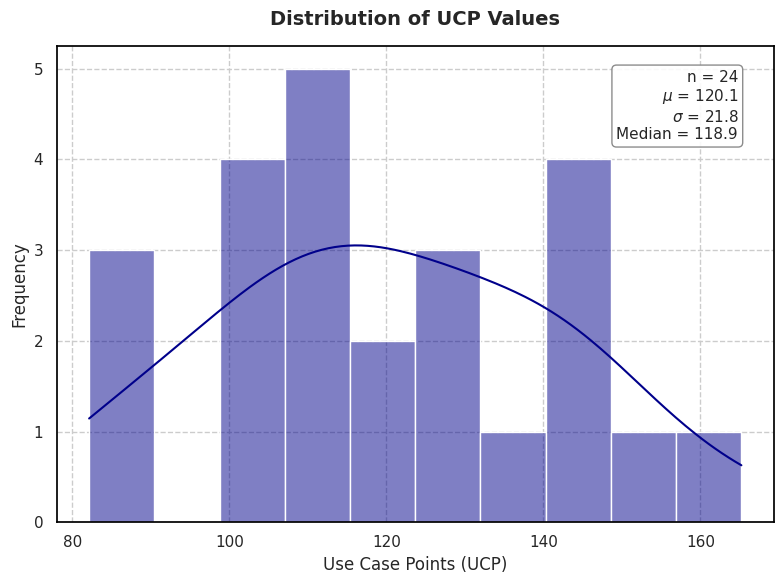

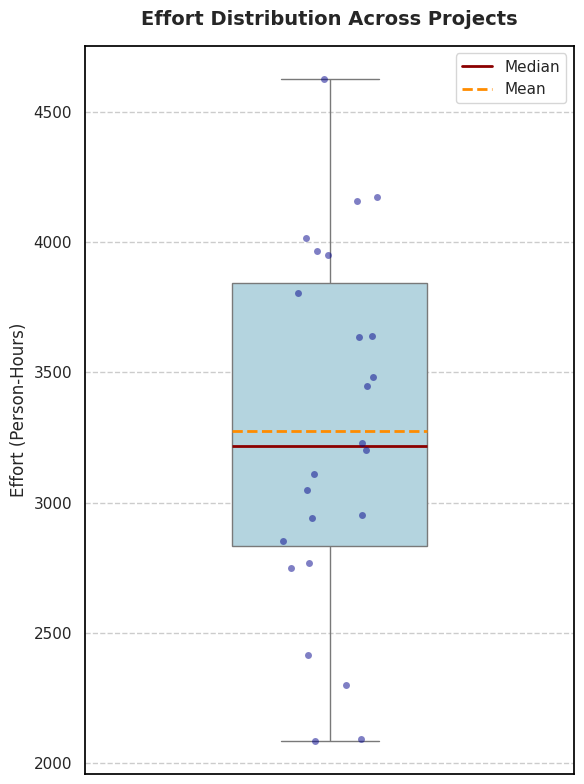

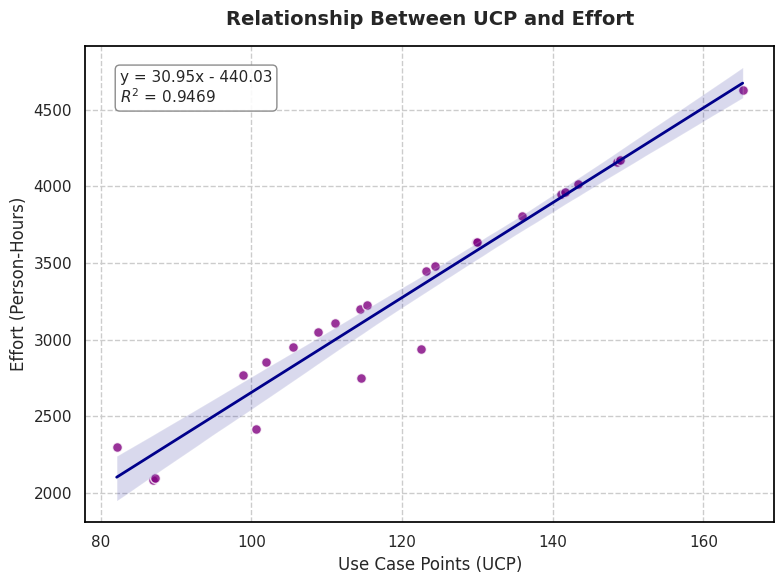

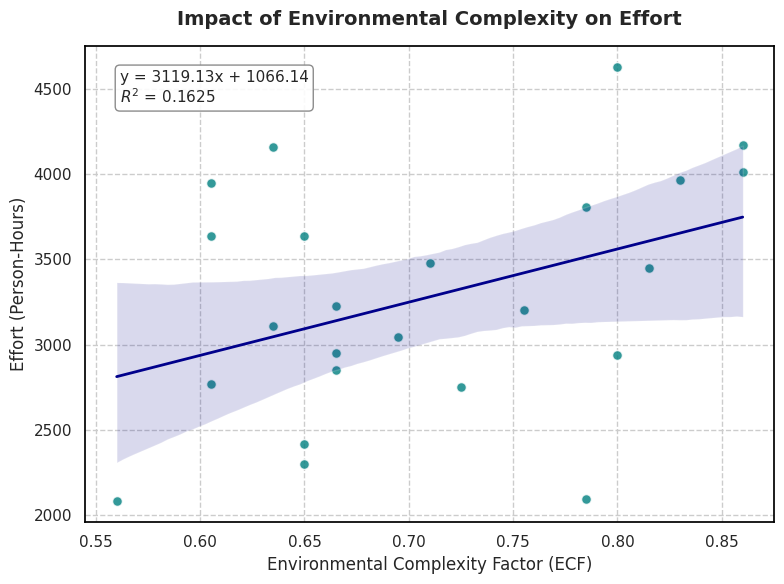

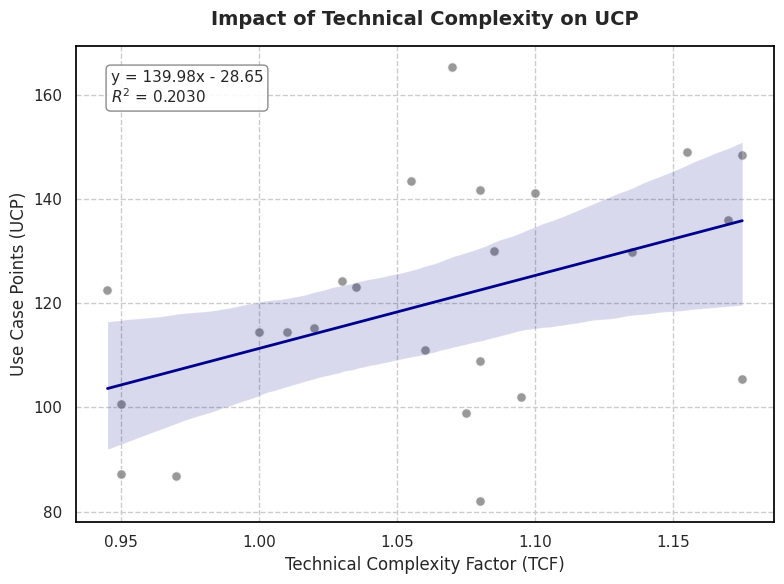

All figures have been generated and saved to your Google Drive!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# 1. Load the data
file_path = "/content/drive/MyDrive/UCP_Synthetic_Results.xlsx"
df = pd.read_excel(file_path)

# Drop the 'Incomplete' row (Food Delivery) to only plot successful calculations
df = df.dropna(subset=['UCP', 'Effort (Person-Hours)'])

# Set publication style
plt.style.use('default')
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "black", "grid.linestyle": "--"})

# Define save directory
save_dir = "/content/drive/MyDrive/"

# ==========================================
# Fig 3: Histogram of UCP Values
# ==========================================
plt.figure(figsize=(8, 6))
ax = sns.histplot(df['UCP'], bins=10, kde=True, color='darkblue', edgecolor='white')
plt.title('Distribution of UCP Values', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Use Case Points (UCP)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add statistical text box
textstr = f"n = {len(df)}\n$\\mu$ = {df['UCP'].mean():.1f}\n$\\sigma$ = {df['UCP'].std():.1f}\nMedian = {df['UCP'].median():.1f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
plt.gca().text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'Fig3_UCP_Histogram.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# Fig 4: Box Plot of Estimated Effort
# ==========================================
plt.figure(figsize=(6, 8))
sns.boxplot(y=df['Effort (Person-Hours)'], color='lightblue', width=0.4, showmeans=True,
            meanline=True, meanprops={'color': 'darkorange', 'linewidth': 2, 'linestyle': '--'},
            medianprops={'color': 'darkred', 'linewidth': 2})
sns.stripplot(y=df['Effort (Person-Hours)'], color='darkblue', alpha=0.5, jitter=True)

plt.title('Effort Distribution Across Projects', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Effort (Person-Hours)', fontsize=12)

# Add custom legend for lines
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='darkred', lw=2),
                Line2D([0], [0], color='darkorange', lw=2, linestyle='--')]
plt.legend(custom_lines, ['Median', 'Mean'], loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'Fig4_Effort_Boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# Helper function for scatter plots with regression
# ==========================================
def plot_scatter_with_reg(x_col, y_col, title, xlabel, ylabel, filename, color):
    plt.figure(figsize=(8, 6))

    # Calculate regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(df[x_col], df[y_col])
    r_squared = r_value**2

    # Plot
    sns.regplot(x=x_col, y=y_col, data=df, scatter_kws={'color': color, 's': 50, 'edgecolor':'white'},
                line_kws={'color': 'darkblue' if color!='darkblue' else 'red', 'linewidth': 2})

    plt.title(title, fontsize=14, pad=15, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    # Add equation and R^2 text box
    eq_text = f"y = {slope:.2f}x {'+' if intercept > 0 else '-'} {abs(intercept):.2f}\n$R^2$ = {r_squared:.4f}"
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    plt.gca().text(0.05, 0.95, eq_text, transform=plt.gca().transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# Fig 5: UCP vs Effort
# ==========================================
plot_scatter_with_reg('UCP', 'Effort (Person-Hours)',
                      'Relationship Between UCP and Effort',
                      'Use Case Points (UCP)', 'Effort (Person-Hours)',
                      'Fig5_UCP_vs_Effort.png', 'purple')

# ==========================================
# Fig 6: ECF vs Effort
# ==========================================
plot_scatter_with_reg('ECF', 'Effort (Person-Hours)',
                      'Impact of Environmental Complexity on Effort',
                      'Environmental Complexity Factor (ECF)', 'Effort (Person-Hours)',
                      'Fig6_ECF_vs_Effort.png', 'teal')

# ==========================================
# Fig 7: TCF vs UCP
# ==========================================
plot_scatter_with_reg('TCF', 'UCP',
                      'Impact of Technical Complexity on UCP',
                      'Technical Complexity Factor (TCF)', 'Use Case Points (UCP)',
                      'Fig7_TCF_vs_UCP.png', 'gray')

print("All figures have been generated and saved to your Google Drive!")